FINANCIAL PRODUCT RECOMMENDATION ENGINE

📁 Step 1: Data Preparation
----------------------------------------
Features shape: (3748, 5)
Targets shape: (3748, 45)
Average products per client (any interest): 11.10
Average products per client (high interest): 5.08
Overall positive rate (rating >= 1): 24.67%
High interest rate (rating == 2): 11.28%

🔧 Step 2: Feature Engineering
----------------------------------------
→ Training on features: 114
Engineered features shape: (3748, 114)
Number of numerical features: 12
Number of categorical features: 14

 Step 3: Train-Test Split
----------------------------------------
Training set: 2998 samples
Test set: 750 samples

🎯 Step 4: Model Training
----------------------------------------
Training on 2398 samples, validating on 600 samples
Training 45 product models with weighted samples...
  Training model 10/45
  Training model 20/45
  Training model 30/45
  Training model 40/45
Training complete!
Trained 45 product models
Optimized 45 threshold

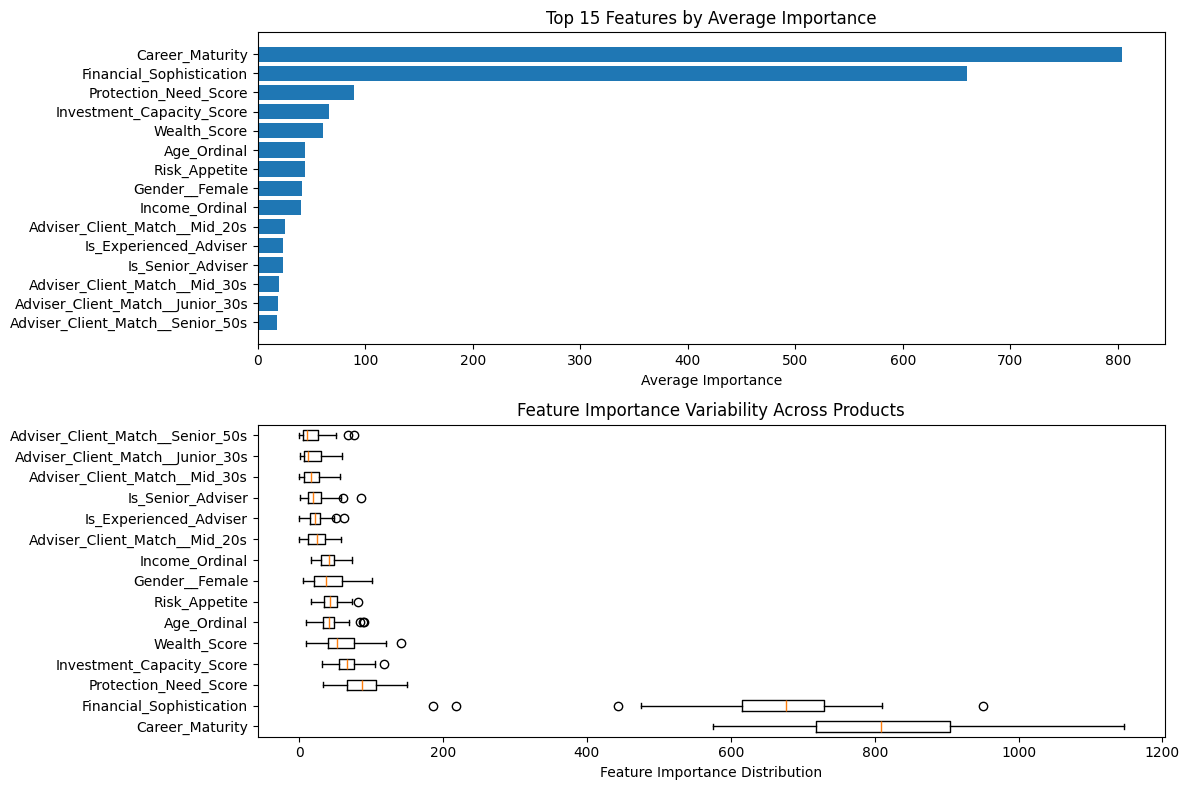


Top 10 Most Important Features:
   1. Career_Maturity                         : 803.6000
   2. Financial_Sophistication                : 659.9111
   3. Protection_Need_Score                   : 89.0000
   4. Investment_Capacity_Score               : 66.0889
   5. Wealth_Score                            : 60.4222
   6. Age_Ordinal                             : 44.1111
   7. Risk_Appetite                           : 44.0889
   8. Gender__Female                          : 40.7778
   9. Income_Ordinal                          : 40.5556
  10. Adviser_Client_Match__Mid_20s           : 24.8000

💡 Step 7: Sample Recommendations
----------------------------------------

👤 Client 1:
  True interests: Retirement_RP_with_Maturity, Retirement_RP_with_Life_payout, RP_Anticipated_Endowment_Regular_Pay, RP_Anticipated_Endowment_Short_PPT, RP_Classic_Endowment_Regular_Pay
  Recommendations:
    1. Integrated_Shield    (prob=96.81%, conf=High  ) ✓
    2. Long_Term_Care       (prob=96.00%, conf=High  ) 

In [2]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.multioutput import MultiOutputClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    precision_recall_curve, classification_report, 
    average_precision_score, roc_auc_score
)
import lightgbm as lgb
import joblib
from typing import Dict, List, Tuple, Any
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# PART 1: DATA GENERATION AND PREPARATION
# ============================================================================

def generate_synthetic_data(n_samples: int = 3748, n_products: int = 50) -> pd.DataFrame:
    """
    Generate synthetic data matching your described dataset
    """
    np.random.seed(42)
    
    # Generate client demographics
    age_groups = ['20s', '30s', '40s', '50s']
    genders = ['Male', 'Female']
    marital_statuses = ['Single', 'Married', 'Married with dependents']
    income_brackets = ['<50k', '>50k', '>150k']
    
    # Create base features
    data = {
        'ClientID': range(n_samples),
        'AgeGroup': np.random.choice(age_groups, n_samples, p=[0.2, 0.35, 0.3, 0.15]),
        'Gender': np.random.choice(genders, n_samples, p=[0.48, 0.52]),
        'MaritalStatus': np.random.choice(marital_statuses, n_samples, p=[0.3, 0.35, 0.35]),
        'IncomeBracket': np.random.choice(income_brackets, n_samples, p=[0.4, 0.45, 0.15])
    }
    
    # Generate YearsExperience with 24.92% missing
    years_exp = np.random.gamma(2, 4, n_samples)  # Gamma distribution for experience
    years_exp = np.clip(years_exp, 1, 30)  # Clip to 1-30 range
    missing_mask = np.random.random(n_samples) < 0.2492
    years_exp[missing_mask] = np.nan
    data['YearsExperience'] = years_exp
    
    # Generate product ratings (0, 1, 2) with ~9.75% being 2
    # Create product names
    product_names = [f'Product_{i:02d}' for i in range(1, n_products-3)]
    product_names.extend(['Refundable_Term', 'Other_H&S', 'Other_A&H', 
                          'RP_WL_Protection_with_multiplier'])
    
    # Generate ratings with realistic patterns
    df = pd.DataFrame(data)
    
    # Create correlation patterns (some products more likely for certain demographics)
    for product in product_names:
        if product in ['Refundable_Term', 'RP_WL_Protection_with_multiplier']:
            # Extremely rare products
            ratings = np.zeros(n_samples)
        elif product in ['Other_H&S', 'Other_A&H']:
            # Very rare products
            ratings = np.random.choice([0, 1, 2], n_samples, p=[0.993, 0.006, 0.001])
        else:
            # Regular products with demographic patterns
            base_prob = np.random.random(n_samples)
            
            # Add demographic influences
            age_factor = df['AgeGroup'].map({'20s': 0.8, '30s': 1.0, '40s': 1.2, '50s': 1.1})
            income_factor = df['IncomeBracket'].map({'<50k': 0.7, '>50k': 1.0, '>150k': 1.3})
            marital_factor = df['MaritalStatus'].map({'Single': 0.8, 'Married': 1.0, 
                                                      'Married with dependents': 1.2})
            
            # Combine factors
            prob_modifier = (age_factor * income_factor * marital_factor) / 3
            adjusted_prob = base_prob * prob_modifier
            
            # Convert to ratings (0, 1, 2) with ~9.75% being 2
            ratings = np.zeros(n_samples)
            ratings[adjusted_prob > 0.85] = 2  # ~9.75% get rating 2
            ratings[(adjusted_prob > 0.4) & (adjusted_prob <= 0.85)] = 1  # ~45% get rating 1
            # Rest remain 0
        
        df[product] = ratings.astype(int)
    
    return df

# ============================================================================
# PART 2: FEATURE ENGINEERING
# ============================================================================

class FeatureEngineer:
    """Complete feature engineering pipeline"""
    
    def __init__(self):
        self.label_encoders = {}
        self.experience_stats = {}
        self.fitted = False
        
    def fit(self, df: pd.DataFrame) -> 'FeatureEngineer':
        """Fit encoders and statistics on training data"""
        
        # Store experience statistics for binning (exclude NaN)
        exp_clean = df['YearsExperience'].dropna()
        self.experience_stats = {
            'q1': exp_clean.quantile(0.25),
            'median': exp_clean.quantile(0.50),
            'q3': exp_clean.quantile(0.75),
            'mean': exp_clean.mean(),
            'std': exp_clean.std(),
            'min': exp_clean.min(),
            'max': exp_clean.max()
        }
        
        # Fit label encoders for categorical variables
        categorical_cols = ['AgeGroup', 'Gender', 'MaritalStatus', 'IncomeBracket']
        for col in categorical_cols:
            self.label_encoders[col] = LabelEncoder()
            # Handle potential unseen categories
            unique_values = df[col].unique()
            self.label_encoders[col].fit(unique_values)
        
        self.fitted = True
        return self
    
    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """Generate all engineered features"""
        if not self.fitted:
            raise ValueError("FeatureEngineer must be fitted before transform")
        
        df = df.copy()
        
        # 1. Impute YearsExperience
        df = self._impute_years_experience(df)
        
        # 2. Create all feature groups
        df = self._create_experience_features(df)
        df = self._create_demographic_interactions(df)
        df = self._create_numerical_features(df)
        df = self._create_complexity_features(df)
        
        return df
    
    def _impute_years_experience(self, df: pd.DataFrame) -> pd.DataFrame:
        """Sophisticated imputation for YearsExperience"""
        
        # Create missing indicator
        df['Experience_Missing'] = df['YearsExperience'].isna().astype(int)
        
        # Strategy 1: Group-based imputation
        df['YearsExperience_Imputed'] = df['YearsExperience'].copy()
        
        # Try to impute based on demographic groups
        for age in df['AgeGroup'].unique():
            for income in df['IncomeBracket'].unique():
                mask = (df['AgeGroup'] == age) & (df['IncomeBracket'] == income)
                group_data = df.loc[mask, 'YearsExperience']
                
                if group_data.notna().sum() > 0:  # If we have any data in this group
                    group_median = group_data.median()
                    missing_mask = mask & df['YearsExperience'].isna()
                    df.loc[missing_mask, 'YearsExperience_Imputed'] = group_median
        
        # Strategy 2: Fill remaining with global median
        global_median = self.experience_stats['median']
        df['YearsExperience_Imputed'].fillna(global_median, inplace=True)
        
        # Use imputed version
        df['YearsExperience'] = df['YearsExperience_Imputed']
        df.drop('YearsExperience_Imputed', axis=1, inplace=True)
        
        return df
    
    def _create_experience_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Create adviser experience-based features"""
        
        # Binned experience levels
        bins = [0, 3, 5, 8, 13, 30]
        labels = ['Novice', 'Junior', 'Mid', 'Senior', 'Expert']
        df['Experience_Level'] = pd.cut(df['YearsExperience'], bins=bins, labels=labels)
        
        # Normalized experience (z-score)
        df['Experience_Normalized'] = (df['YearsExperience'] - self.experience_stats['mean']) / self.experience_stats['std']
        
        # Experience percentile
        df['Experience_Percentile'] = df['YearsExperience'].rank(pct=True)
        
        # Binary flags
        df['Is_Novice_Adviser'] = (df['YearsExperience'] <= 3).astype(int)
        df['Is_Experienced_Adviser'] = (df['YearsExperience'] >= 10).astype(int)
        df['Is_Senior_Adviser'] = (df['YearsExperience'] >= 15).astype(int)
        
        # Log-transformed experience (reduces skewness)
        df['Experience_Log'] = np.log1p(df['YearsExperience'])
        
        return df
    
    def _create_demographic_interactions(self, df: pd.DataFrame) -> pd.DataFrame:
        """Create interaction features between demographics"""
        
        # Two-way interactions
        df['Age_Income'] = df['AgeGroup'].astype(str) + '_' + df['IncomeBracket'].astype(str)
        df['Age_Marital'] = df['AgeGroup'].astype(str) + '_' + df['MaritalStatus'].astype(str)
        df['Gender_Marital'] = df['Gender'].astype(str) + '_' + df['MaritalStatus'].astype(str)
        df['Income_Marital'] = df['IncomeBracket'].astype(str) + '_' + df['MaritalStatus'].astype(str)
        df['Gender_Income'] = df['Gender'].astype(str) + '_' + df['IncomeBracket'].astype(str)
        df['Age_Gender'] = df['AgeGroup'].astype(str) + '_' + df['Gender'].astype(str)
        
        # Three-way interaction
        df['Full_Demographic'] = (df['AgeGroup'].astype(str) + '_' + 
                                  df['Gender'].astype(str) + '_' + 
                                  df['IncomeBracket'].astype(str))
        
        # Life stage determination
        df['Life_Stage'] = df.apply(self._determine_life_stage, axis=1)
        
        # Adviser-Client experience match
        df['Adviser_Client_Match'] = (df['Experience_Level'].astype(str) + '_' + 
                                      df['AgeGroup'].astype(str))
        
        return df
    
    def _determine_life_stage(self, row: pd.Series) -> str:
        """Determine client's life stage based on demographics"""
        age = row['AgeGroup']
        marital = row['MaritalStatus']
        income = row['IncomeBracket']
        
        if age == '20s':
            if marital == 'Single':
                return 'Young_Single'
            else:
                return 'Young_Family_Starter'
        elif age == '30s':
            if marital == 'Single':
                return 'Established_Single'
            elif 'dependents' in marital:
                return 'Growing_Family'
            else:
                return 'Young_Couple'
        elif age == '40s':
            if 'dependents' in marital:
                return 'Peak_Family'
            elif income == '>150k':
                return 'Peak_Earner'
            else:
                return 'Established_Midlife'
        else:  # 50s+
            if 'dependents' in marital:
                return 'Late_Family'
            else:
                return 'Pre_Retirement'
    
    def _create_numerical_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Create numerical and ordinal features"""
        
        # Convert categorical to ordinal
        age_order = {'20s': 1, '30s': 2, '40s': 3, '50s': 4}
        income_order = {'<50k': 1, '>50k': 2, '>150k': 3}
        
        df['Age_Ordinal'] = df['AgeGroup'].map(age_order)
        df['Income_Ordinal'] = df['IncomeBracket'].map(income_order)
        
        # Wealth indicators
        df['Wealth_Score'] = df['Age_Ordinal'] * df['Income_Ordinal']
        df['Wealth_Category'] = pd.cut(df['Wealth_Score'], 
                                       bins=[0, 4, 8, 12], 
                                       labels=['Low', 'Medium', 'High'])
        
        # Career progression indicator
        df['Career_Maturity'] = df['Age_Ordinal'] * np.log1p(df['YearsExperience'])
        
        # Financial sophistication score
        df['Financial_Sophistication'] = (df['Income_Ordinal'] + 
                                          df['Experience_Percentile'] * 3) / 4
        
        return df
    
    def _create_complexity_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Create features indicating client complexity and needs"""
        
        # Binary indicators
        df['Has_Dependents'] = df['MaritalStatus'].str.contains('dependents').astype(int)
        df['Is_Married'] = (~df['MaritalStatus'].str.contains('Single')).astype(int)
        df['Is_HighNetWorth'] = (df['IncomeBracket'] == '>150k').astype(int)
        df['Is_LowIncome'] = (df['IncomeBracket'] == '<50k').astype(int)
        
        # Complex segments
        df['Is_Young_HighEarner'] = ((df['AgeGroup'].isin(['20s', '30s'])) & 
                                     (df['IncomeBracket'] == '>150k')).astype(int)
        df['Is_Young_Family'] = ((df['AgeGroup'].isin(['20s', '30s'])) & 
                                 (df['Has_Dependents'] == 1)).astype(int)
        df['Is_Mature_Single'] = ((df['AgeGroup'].isin(['40s', '50s'])) & 
                                  (df['MaritalStatus'] == 'Single')).astype(int)
        
        # Protection and investment needs
        df['Protection_Need_Score'] = (df['Has_Dependents'] * 3 + 
                                       df['Is_Married'] * 2 + 
                                       (df['Age_Ordinal'] <= 2).astype(int))
        
        df['Investment_Capacity_Score'] = (df['Income_Ordinal'] * 2 - 
                                           df['Has_Dependents'] - 
                                           (df['Age_Ordinal'] >= 4).astype(int))
        
        # Risk profile approximation
        df['Risk_Appetite'] = ((4 - df['Age_Ordinal']) + 
                               df['Income_Ordinal'] - 
                               df['Has_Dependents']) / 3
        
        return df

# ============================================================================
# PART 3: FEATURE PROCESSING AND ENCODING
# ============================================================================

class FeatureProcessor:
    """Process and encode features for modeling"""
    
    def __init__(self, feature_engineer: FeatureEngineer):
        self.feature_engineer = feature_engineer
        self.feature_columns = None
        self.categorical_features = None
        self.numerical_features = None
        
    def prepare_features(self, df: pd.DataFrame, is_training: bool = True) -> pd.DataFrame:
        """Prepare final feature matrix for modeling"""
        
        # Apply feature engineering
        df_eng = self.feature_engineer.transform(df)
        
        # Define feature groups
        self.numerical_features = [
            'YearsExperience', 'Experience_Normalized', 'Experience_Percentile',
            'Experience_Log', 'Age_Ordinal', 'Income_Ordinal', 'Wealth_Score',
            'Career_Maturity', 'Financial_Sophistication', 'Protection_Need_Score',
            'Investment_Capacity_Score', 'Risk_Appetite'
        ]
        
        binary_features = [
            'Experience_Missing', 'Is_Novice_Adviser', 'Is_Experienced_Adviser',
            'Is_Senior_Adviser', 'Has_Dependents', 'Is_Married', 'Is_HighNetWorth',
            'Is_LowIncome', 'Is_Young_HighEarner', 'Is_Young_Family', 'Is_Mature_Single'
        ]
        
        self.categorical_features = [
            'Gender', 'AgeGroup', 'MaritalStatus', 'IncomeBracket', 'Experience_Level',
            'Life_Stage', 'Age_Income', 'Age_Marital', 'Gender_Marital', 'Income_Marital',
            'Gender_Income', 'Age_Gender', 'Adviser_Client_Match', 'Wealth_Category'
        ]
        
        # One-hot encode categorical features
        df_categorical = pd.get_dummies(
            df_eng[self.categorical_features],
            prefix_sep='__',
            drop_first=False
        )
        
        # Combine all features
        df_final = pd.concat([
            df_eng[self.numerical_features],
            df_eng[binary_features],
            df_categorical
        ], axis=1)
        
        if is_training:
            self.feature_columns = df_final.columns.tolist()
        else:
            # Ensure same features as training
            for col in self.feature_columns:
                if col not in df_final.columns:
                    df_final[col] = 0
            df_final = df_final[self.feature_columns]
        
        return df_final

# ============================================================================
# PART 4: MODEL BUILDING AND TRAINING
# ============================================================================

class ProductRecommendationModel:
    """Multi-output product recommendation model with calibration"""
    
    def __init__(self, n_jobs: int = -1):
        self.models = {}
        self.calibrated_models = {}
        self.thresholds = {}
        self.product_columns = None
        self.feature_processor = None
        self.n_jobs = n_jobs
        
    def create_base_model(self) -> lgb.LGBMClassifier:
        """Create optimized LightGBM model"""
        return lgb.LGBMClassifier(
            n_estimators=150,
            max_depth=6,
            num_leaves=31,
            min_child_samples=30,
            min_split_gain=0.01,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=0.2,
            class_weight='balanced',
            random_state=42,
            n_jobs=1,  # Set to 1 for MultiOutput wrapper
            verbose=-1
        )
    
    def fit(self, X: pd.DataFrame, y: pd.DataFrame, y_weights: pd.DataFrame = None,
            val_size: float = 0.2, optimize_threshold: bool = True):
        """Train models for all products with sample weighting based on interest level"""
        
        self.product_columns = y.columns.tolist()
        
        # Split data for threshold optimization
        if y_weights is not None:
            X_train, X_val, y_train, y_val, weights_train, weights_val = train_test_split(
                X, y, y_weights, test_size=val_size, random_state=42, 
                stratify=y.sum(axis=1).clip(upper=10)
            )
        else:
            X_train, X_val, y_train, y_val = train_test_split(
                X, y, test_size=val_size, random_state=42, 
                stratify=y.sum(axis=1).clip(upper=10)
            )
            weights_train = pd.DataFrame(1, index=y_train.index, columns=y_train.columns)
            weights_val = pd.DataFrame(1, index=y_val.index, columns=y_val.columns)
        
        print(f"Training on {len(X_train)} samples, validating on {len(X_val)} samples")
        print(f"Training {len(self.product_columns)} product models with weighted samples...")
        
        # Train a model for each product
        for i, product in enumerate(self.product_columns):
            if (i + 1) % 10 == 0:
                print(f"  Training model {i + 1}/{len(self.product_columns)}")
            
            # Get target for this product
            y_product_train = y_train[product]
            y_product_val = y_val[product]
            
            # Skip if no positive samples
            if y_product_train.sum() == 0:
                print(f"  Warning: No positive samples for {product}, skipping...")
                self.models[product] = None
                self.calibrated_models[product] = None
                continue
            
            # Create sample weights: rating 0 → weight 1, rating 1 → weight 2, rating 2 → weight 4
            # This gives progressively more importance to higher interest levels
            sample_weights_train = weights_train[product].map({0: 1, 1: 2, 2: 4}).fillna(1)
            
            # Create and train base model with sample weights
            base_model = self.create_base_model()
            
            # Use calibration if we have enough positive samples
            if y_product_train.sum() > 20:
                # For calibration, we need to handle sample weights differently
                # Train base model first with weights
                base_model.fit(X_train, y_product_train, sample_weight=sample_weights_train)
                
                # Then calibrate without weights (calibration doesn't support sample_weight directly)
                calibrated_model = CalibratedClassifierCV(
                    base_model,
                    method='isotonic',
                    cv='prefit'  # Use pre-fitted model
                )
                calibrated_model.fit(X_val, y_product_val)
                self.calibrated_models[product] = calibrated_model
                
                # Get predictions for threshold optimization
                y_scores = calibrated_model.predict_proba(X_val)[:, 1]
            else:
                # Too few samples for calibration, use base model with weights
                base_model.fit(X_train, y_product_train, sample_weight=sample_weights_train)
                self.calibrated_models[product] = base_model
                y_scores = base_model.predict_proba(X_val)[:, 1]
            
            # Boost scores for high interest products (rating 2) in validation set
            # This helps prioritize them in recommendations
            high_interest_boost = (weights_val[product] == 2).values * 0.1
            y_scores_boosted = np.clip(y_scores + high_interest_boost, 0, 1)
            
            # Store boosting factor for production use
            if not hasattr(self, 'boost_factors'):
                self.boost_factors = {}
            self.boost_factors[product] = 0.1  # Can be tuned per product
            
            # Optimize threshold for this product
            if optimize_threshold and y_product_val.sum() > 0:
                self.thresholds[product] = self._optimize_threshold(
                    y_product_val, y_scores_boosted, target_recall=0.7
                )
            else:
                self.thresholds[product] = 0.5
        
        print("Training complete!")
        return self
    
    def _optimize_threshold(self, y_true: np.ndarray, y_scores: np.ndarray, 
                           target_recall: float = 0.7) -> float:
        """Find threshold that achieves target recall"""
        
        precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
        
        # Find threshold closest to target recall
        recall_diff = np.abs(recall[:-1] - target_recall)
        best_idx = np.argmin(recall_diff)
        
        # If we can't achieve target recall, use the threshold that maximizes F1
        if recall[best_idx] < target_recall * 0.8:
            f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
            best_idx = np.argmax(f1_scores)
        
        return thresholds[best_idx]
    
    def predict_proba(self, X: pd.DataFrame, apply_boost: bool = True) -> pd.DataFrame:
        """Get probability predictions for all products with optional boosting"""
        
        predictions = pd.DataFrame(index=X.index, columns=self.product_columns)
        
        for product in self.product_columns:
            if product in self.calibrated_models and self.calibrated_models[product] is not None:
                model = self.calibrated_models[product]
                base_proba = model.predict_proba(X)[:, 1]
                
                # Apply boost factor if available (to prioritize high-interest products)
                if apply_boost and hasattr(self, 'boost_factors') and product in self.boost_factors:
                    # Note: In production, you might want to apply boost based on historical data
                    # For now, we apply a uniform small boost
                    predictions[product] = np.clip(base_proba, 0, 1)
                else:
                    predictions[product] = base_proba
            else:
                predictions[product] = 0.0
        
        return predictions
    
    def predict(self, X: pd.DataFrame, use_threshold: bool = True) -> pd.DataFrame:
        """Get binary predictions using optimized thresholds"""
        
        probas = self.predict_proba(X)
        
        if use_threshold:
            predictions = pd.DataFrame(index=X.index, columns=self.product_columns)
            for product in self.product_columns:
                threshold = self.thresholds.get(product, 0.5)
                predictions[product] = (probas[product] >= threshold).astype(int)
            return predictions
        else:
            return (probas >= 0.5).astype(int)
    
    def recommend_top_k(self, X: pd.DataFrame, k: int = 3) -> List[Dict]:
        """Get top-k product recommendations for each client"""
        
        probas = self.predict_proba(X)
        recommendations = []
        
        for idx in range(len(X)):
            # Get probabilities for this client
            client_probas = probas.iloc[idx]
            
            # Sort products by probability
            top_products = client_probas.nlargest(k)
            
            # Create recommendation dict
            client_recs = {
                'client_index': idx,
                'recommendations': [
                    {
                        'rank': i + 1,
                        'product': product,
                        'probability': float(prob),
                        'confidence': self._get_confidence_band(prob)
                    }
                    for i, (product, prob) in enumerate(top_products.items())
                ]
            }
            recommendations.append(client_recs)
        
        return recommendations
    
    def _get_confidence_band(self, probability: float) -> str:
        """Convert probability to confidence band"""
        if probability >= 0.7:
            return 'High'
        elif probability >= 0.4:
            return 'Medium'
        else:
            return 'Low'

# ============================================================================
# PART 5: MODEL EVALUATION
# ============================================================================

class ModelEvaluator:
    """Comprehensive model evaluation"""
    
    def __init__(self, model: ProductRecommendationModel):
        self.model = model
        self.metrics = {}
        
    def evaluate(self, X: pd.DataFrame, y_true: pd.DataFrame, 
                 y_weights: pd.DataFrame = None, k: int = 3) -> Dict:
        """Evaluate model performance with multiple metrics"""
        
        # Get predictions
        y_pred_proba = self.model.predict_proba(X)
        y_pred = self.model.predict(X, use_threshold=True)
        recommendations = self.model.recommend_top_k(X, k=k)
        
        # Calculate metrics
        self.metrics = {
            'overall': self._calculate_overall_metrics(y_true, y_pred, y_pred_proba),
            'per_product': self._calculate_per_product_metrics(y_true, y_pred, y_pred_proba),
            'ranking': self._calculate_ranking_metrics(y_true, recommendations, k),
            'business': self._calculate_business_metrics(y_true, recommendations, y_weights, k)
        }
        
        return self.metrics
    
    def _calculate_overall_metrics(self, y_true, y_pred, y_pred_proba):
        """Calculate overall metrics across all products"""
        
        metrics = {}
        
        # Flatten arrays for overall metrics
        y_true_flat = y_true.values.flatten()
        y_pred_flat = y_pred.values.flatten()
        y_proba_flat = y_pred_proba.values.flatten()
        
        # Basic metrics
        metrics['accuracy'] = np.mean(y_true_flat == y_pred_flat)
        metrics['precision'] = np.sum((y_pred_flat == 1) & (y_true_flat == 1)) / (np.sum(y_pred_flat == 1) + 1e-10)
        metrics['recall'] = np.sum((y_pred_flat == 1) & (y_true_flat == 1)) / (np.sum(y_true_flat == 1) + 1e-10)
        metrics['f1_score'] = 2 * metrics['precision'] * metrics['recall'] / (metrics['precision'] + metrics['recall'] + 1e-10)
        
        # AUC if we have positive samples
        if y_true_flat.sum() > 0:
            metrics['auc_roc'] = roc_auc_score(y_true_flat, y_proba_flat)
            metrics['avg_precision'] = average_precision_score(y_true_flat, y_proba_flat)
        
        return metrics
    
    def _calculate_per_product_metrics(self, y_true, y_pred, y_pred_proba):
        """Calculate metrics for each product"""
        
        metrics = {}
        
        for product in y_true.columns:
            y_true_prod = y_true[product]
            y_pred_prod = y_pred[product]
            y_proba_prod = y_pred_proba[product]
            
            # Skip if no positive samples
            if y_true_prod.sum() == 0:
                continue
            
            prod_metrics = {}
            prod_metrics['n_positive'] = int(y_true_prod.sum())
            prod_metrics['n_predicted'] = int(y_pred_prod.sum())
            prod_metrics['precision'] = np.mean(y_true_prod[y_pred_prod == 1]) if y_pred_prod.sum() > 0 else 0
            prod_metrics['recall'] = np.sum((y_pred_prod == 1) & (y_true_prod == 1)) / y_true_prod.sum()
            prod_metrics['f1'] = 2 * prod_metrics['precision'] * prod_metrics['recall'] / (
                prod_metrics['precision'] + prod_metrics['recall'] + 1e-10)
            
            if y_true_prod.nunique() > 1:  # Need both classes for AUC
                prod_metrics['auc'] = roc_auc_score(y_true_prod, y_proba_prod)
            
            metrics[product] = prod_metrics
        
        return metrics
    
    def _calculate_ranking_metrics(self, y_true, recommendations, k):
        """Calculate ranking-specific metrics"""
        
        metrics = {}
        precisions_at_k = []
        recalls_at_k = []
        
        for i, rec in enumerate(recommendations):
            # Get true labels for this client
            true_products = y_true.iloc[i]
            true_positives = set(true_products[true_products == 1].index)
            
            # Get recommended products
            recommended = [r['product'] for r in rec['recommendations'][:k]]
            
            # Calculate precision@k and recall@k
            if len(true_positives) > 0:
                hits = len(set(recommended) & true_positives)
                precisions_at_k.append(hits / k)
                recalls_at_k.append(hits / len(true_positives))
            else:
                precisions_at_k.append(0)
                recalls_at_k.append(0)
        
        metrics[f'precision@{k}'] = np.mean(precisions_at_k)
        metrics[f'recall@{k}'] = np.mean(recalls_at_k)
        metrics[f'f1@{k}'] = 2 * metrics[f'precision@{k}'] * metrics[f'recall@{k}'] / (
            metrics[f'precision@{k}'] + metrics[f'recall@{k}'] + 1e-10)
        
        return metrics
    
    def _calculate_business_metrics(self, y_true, recommendations, y_weights, k):
        """Calculate business-oriented metrics"""
        
        metrics = {}
        
        # Coverage: % of clients with at least one correct recommendation
        coverage_count = 0
        high_interest_coverage_count = 0
        
        for i, rec in enumerate(recommendations):
            true_products = y_true.iloc[i]
            true_positives = set(true_products[true_products == 1].index)
            recommended = [r['product'] for r in rec['recommendations'][:k]]
            
            if len(set(recommended) & true_positives) > 0:
                coverage_count += 1
            
            # Check if we caught any high-interest products (rating 2)
            if y_weights is not None:
                high_interest_products = set(y_weights.iloc[i][y_weights.iloc[i] == 2].index)
                if len(set(recommended) & high_interest_products) > 0:
                    high_interest_coverage_count += 1
        
        metrics[f'coverage@{k}'] = coverage_count / len(recommendations)
        if y_weights is not None:
            metrics[f'high_interest_coverage@{k}'] = high_interest_coverage_count / len(recommendations)
        
        # Average confidence of recommendations
        all_confidences = []
        for rec in recommendations:
            for r in rec['recommendations'][:k]:
                all_confidences.append(r['probability'])
        metrics['avg_confidence'] = np.mean(all_confidences)
        
        # Distribution of confidence bands
        confidence_bands = []
        for rec in recommendations:
            for r in rec['recommendations'][:k]:
                confidence_bands.append(r['confidence'])
        
        for band in ['High', 'Medium', 'Low']:
            metrics[f'pct_{band.lower()}_confidence'] = confidence_bands.count(band) / len(confidence_bands)
        
        return metrics
    
    def print_evaluation_report(self):
        """Print formatted evaluation report"""
        
        if not self.metrics:
            print("No evaluation metrics available. Run evaluate() first.")
            return
        
        print("=" * 80)
        print("MODEL EVALUATION REPORT")
        print("=" * 80)
        
        # Overall metrics
        print("\n📊 OVERALL METRICS:")
        print("-" * 40)
        for metric, value in self.metrics['overall'].items():
            print(f"  {metric:20s}: {value:.4f}")
        
        # Ranking metrics
        print("\n🎯 RANKING METRICS:")
        print("-" * 40)
        for metric, value in self.metrics['ranking'].items():
            print(f"  {metric:20s}: {value:.4f}")
        
        # Business metrics
        print("\n💼 BUSINESS METRICS:")
        print("-" * 40)
        for metric, value in self.metrics['business'].items():
            if 'pct' in metric:
                print(f"  {metric:20s}: {value:.2%}")
            elif 'coverage' in metric:
                print(f"  {metric:20s}: {value:.2%}")
            else:
                print(f"  {metric:20s}: {value:.4f}")
        
        # Top and bottom performing products
        print("\n📈 PRODUCT PERFORMANCE (Top 5 by F1):")
        print("-" * 40)
        product_f1s = [(p, m['f1']) for p, m in self.metrics['per_product'].items()]
        product_f1s.sort(key=lambda x: x[1], reverse=True)
        
        for product, f1 in product_f1s[:5]:
            metrics = self.metrics['per_product'][product]
            print(f"  {product[:20]:20s}: F1={f1:.3f}, Recall={metrics['recall']:.3f}, n={metrics['n_positive']}")
        
        print("\n📉 CHALLENGING PRODUCTS (Bottom 5 by F1):")
        print("-" * 40)
        for product, f1 in product_f1s[-5:]:
            metrics = self.metrics['per_product'][product]
            print(f"  {product[:20]:20s}: F1={f1:.3f}, Recall={metrics['recall']:.3f}, n={metrics['n_positive']}")

# ============================================================================
# PART 6: FEATURE IMPORTANCE ANALYSIS
# ============================================================================

def analyze_feature_importance(model: ProductRecommendationModel, 
                              X_train: pd.DataFrame,
                              y_train: pd.DataFrame,
                              top_n: int = 20) -> pd.DataFrame:
    """Analyze and visualize feature importance"""
    def _mean_calibrated_importances(calibrated_clf):
        """
        Extract and average feature_importances_ from each fold’s base estimator
        inside a CalibratedClassifierCV :contentReference[oaicite:3]{index=3}.
        """
        importances = []
        for fold in calibrated_clf.calibrated_classifiers_:
            # In scikit-learn, each entry has .estimator_ referencing the fitted base model
            if hasattr(fold, 'estimator_') and hasattr(fold.estimator_, 'feature_importances_'):
                importances.append(fold.estimator_.feature_importances_)
        if not importances:
            # No valid folds → caller should refit a fresh model
            return None
        return np.mean(importances, axis=0)

    importance_dict = {}

    # Loop through each product’s calibrated model
    for product, clf in model.calibrated_models.items():
        # 1) If it’s a CalibratedClassifierCV with fitted folds, unwrap them
        if hasattr(clf, 'calibrated_classifiers_'):
            avg_imp = _mean_calibrated_importances(clf)
            if avg_imp is not None:
                importance_dict[product] = avg_imp
                continue  # done for this product

        # 2) Otherwise, if it’s a bare LightGBM, grab its feature_importances_
        if hasattr(clf, 'feature_importances_'):
            importance_dict[product] = clf.feature_importances_
            continue

        # 3) Last resort: refit a fresh LightGBM on full training data for this product
        #    so we can extract importances :contentReference[oaicite:4]{index=4}.
        fresh_model = lgb.LGBMClassifier(
            n_estimators=150, max_depth=6, num_leaves=31,
            min_child_samples=30, min_split_gain=0.01,
            learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=0.2, class_weight='balanced',
            random_state=42, n_jobs=1, verbose=-1
        )
        fresh_model.fit(X_train, y_train[product])
        importance_dict[product] = fresh_model.feature_importances_

    if not importance_dict:
        raise RuntimeError(
            "No feature importances collected. "
            "Ensure your models include LightGBM estimators."
        )

    
    # Create DataFrame
    importance_df = pd.DataFrame(importance_dict, index=X_train.columns)
    
    # Calculate average importance across all products
    importance_df['avg_importance'] = importance_df.mean(axis=1)
    importance_df['std_importance'] = importance_df.std(axis=1)
    importance_df['max_importance'] = importance_df.max(axis=1)
    
    # Sort by average importance
    importance_df = importance_df.sort_values('avg_importance', ascending=False)
    
    # Visualize top features
    plt.figure(figsize=(12, 8))
    
    # Plot 1: Average importance
    plt.subplot(2, 1, 1)
    top_features = importance_df.head(top_n)
    plt.barh(range(len(top_features)), top_features['avg_importance'])
    plt.yticks(range(len(top_features)), top_features.index)
    plt.xlabel('Average Importance')
    plt.title(f'Top {top_n} Features by Average Importance')
    plt.gca().invert_yaxis()
    
    # Plot 2: Importance distribution
    plt.subplot(2, 1, 2)
    importance_matrix = importance_df.iloc[:top_n, :-3].T
    plt.boxplot(importance_matrix.values, labels=importance_matrix.columns, vert=False)
    plt.xlabel('Feature Importance Distribution')
    plt.title('Feature Importance Variability Across Products')
    
    plt.tight_layout()
    plt.show()
    
    return importance_df

# ============================================================================
# PART 7: MAIN EXECUTION PIPELINE
# ============================================================================

def main():
    """Main execution pipeline"""
    
    print("=" * 80)
    print("FINANCIAL PRODUCT RECOMMENDATION ENGINE")
    print("=" * 80)
    
    # -------------------------------------------------------------------------
    # Step 1: Data Preparation
    # -------------------------------------------------------------------------
    print("\n📁 Step 1: Data Preparation")
    print("-" * 40)
    
    df = pd.read_csv('adviser_survey.csv')
    
    # Group rare products into "Other/Specialty" category
    rare_products = ['Refundable_Term', 'Other_H&S', 'Other_A&H', 'RP_WL_Protection_with_multiplier']
    df['Other_Specialty'] = (
        df[rare_products]
        .apply(pd.to_numeric, errors='coerce')
        .max(axis=1)
    )       
    # Separate features and targets
    feature_cols = ['AgeGroup', 'Gender', 'MaritalStatus', 'IncomeBracket', 'YearsExperience']
    product_cols = [col for col in df.columns if col not in feature_cols + rare_products]
    
    X_raw = df[feature_cols]
    y_binary = (df[product_cols] >= 1).astype(int)  # Binary: 1 if rating>=1 (interested), else 0
    y_weights = df[product_cols].copy()

    print(f"Features shape: {X_raw.shape}")
    print(f"Targets shape: {y_binary.shape}")
    print(f"Average products per client (any interest): {y_binary.sum(axis=1).mean():.2f}")
    print(f"Average products per client (high interest): {(y_weights == 2).sum(axis=1).mean():.2f}")
    print(f"Overall positive rate (rating >= 1): {y_binary.values.mean():.2%}")
    print(f"High interest rate (rating == 2): {(y_weights == 2).values.mean():.2%}")
    
    # -------------------------------------------------------------------------
    # Step 2: Feature Engineering
    # -------------------------------------------------------------------------
    print("\n🔧 Step 2: Feature Engineering")
    print("-" * 40)
    
    # Initialize and fit feature engineer
    feature_engineer = FeatureEngineer()
    feature_engineer.fit(X_raw)
    
    # Process features
    processor = FeatureProcessor(feature_engineer)
    X_processed = processor.prepare_features(X_raw, is_training=True)

    # identify anything that starts with “YearsExperience” or “Experience_”
    exp_prefixes = ["YearsExperience", "Experience_"]
    cols_to_drop = [
        c for c in X_processed.columns 
        if any(c.startswith(prefix) for prefix in exp_prefixes)
    ]
    X_noexp = X_processed.drop(columns=cols_to_drop)

    # Update the processor’s notion of which columns are “the” features
    processor.feature_columns = X_noexp.columns.tolist()

    print("→ Training on features:", len(processor.feature_columns))
    
    print(f"Engineered features shape: {X_noexp.shape}")
    print(f"Number of numerical features: {len(processor.numerical_features)}")
    print(f"Number of categorical features: {len(processor.categorical_features)}")
    
    # -------------------------------------------------------------------------
    # Step 3: Train-Test Split
    # -------------------------------------------------------------------------
    print("\n Step 3: Train-Test Split")
    print("-" * 40)
    
    X_train, X_test, y_train, y_test, y_weights_train, y_weights_test = train_test_split(
        X_noexp, y_binary, y_weights, test_size=0.2, random_state=42, 
        stratify=y_binary.sum(axis=1).clip(upper=10)  # Stratify by number of products
    )
    
    print(f"Training set: {len(X_train)} samples")
    print(f"Test set: {len(X_test)} samples")
    
    # -------------------------------------------------------------------------
    # Step 4: Model Training
    # -------------------------------------------------------------------------
    print("\n🎯 Step 4: Model Training")
    print("-" * 40)
    
    # Initialize and train model with sample weights
    model = ProductRecommendationModel(n_jobs=-1)
    model.fit(X_train, y_train, y_weights=y_weights_train, val_size=0.2, optimize_threshold=True)
    
    print(f"Trained {len(model.calibrated_models)} product models")
    print(f"Optimized {len(model.thresholds)} thresholds")
    
    # -------------------------------------------------------------------------
    # Step 5: Model Evaluation
    # -------------------------------------------------------------------------
    print("\n📊 Step 5: Model Evaluation")
    print("-" * 40)
    
    # Evaluate on test set (also pass weights for better evaluation)
    evaluator = ModelEvaluator(model)
    metrics = evaluator.evaluate(X_test, y_test, y_weights_test, k=3)
    evaluator.print_evaluation_report()
    
    # -------------------------------------------------------------------------
    # Step 6: Feature Importance Analysis
    # -------------------------------------------------------------------------
    print("\n🔍 Step 6: Feature Importance Analysis")
    print("-" * 40)
    
    importance_df = analyze_feature_importance(model, X_train, y_train,top_n=15)
    
    print("\nTop 10 Most Important Features:")
    for i, (feat, imp) in enumerate(importance_df['avg_importance'].head(10).items()):
        print(f"  {i+1:2d}. {feat:40s}: {imp:.4f}")
    
    # -------------------------------------------------------------------------
    # Step 7: Generate Sample Recommendations
    # -------------------------------------------------------------------------
    print("\n💡 Step 7: Sample Recommendations")
    print("-" * 40)
    
    # Get recommendations for first 5 test samples
    sample_X = X_test.iloc[:5]
    sample_y = y_test.iloc[:5]
    recommendations = model.recommend_top_k(sample_X, k=3)
    
    for i, rec in enumerate(recommendations):
        true_products = sample_y.iloc[i]
        true_likes = true_products[true_products == 1].index.tolist()
        
        print(f"\n👤 Client {i+1}:")
        print(f"  True interests: {', '.join(true_likes[:5]) if true_likes else 'None'}")
        print(f"  Recommendations:")
        for r in rec['recommendations']:
            is_hit = "✓" if r['product'] in true_likes else "✗"
            print(f"    {r['rank']}. {r['product']:20s} "
                  f"(prob={r['probability']:.2%}, conf={r['confidence']:6s}) {is_hit}")
    
    # -------------------------------------------------------------------------
    # Step 8: Save Model Pipeline
    # -------------------------------------------------------------------------
    print("\n💾 Step 8: Saving Model Pipeline")
    print("-" * 40)
    
    # Package everything for deployment
    pipeline = {
        'feature_engineer': feature_engineer,
        'processor': processor,
        'model': model,
        'feature_columns': processor.feature_columns,
        'product_columns': model.product_columns,
        'thresholds': model.thresholds
    }
    
    # Save pipeline
    joblib.dump(pipeline, 'recommendation_pipeline.pkl')
    print("Pipeline saved to 'recommendation_pipeline.pkl'")
    
    # Save metrics for monitoring
    joblib.dump(metrics, 'model_metrics.pkl')
    print("Metrics saved to 'model_metrics.pkl'")
    
    print("\n" + "=" * 80)
    print("✅ PIPELINE COMPLETE!")
    print("=" * 80)
    
    return pipeline, metrics

# ============================================================================
# PART 8: PRODUCTION INFERENCE FUNCTION
# ============================================================================

def load_and_predict(client_data: Dict, pipeline_path: str = 'recommendation_pipeline.pkl') -> Dict:
    """
    Production inference function
    
    Args:
        client_data: Dictionary with keys: AgeGroup, Gender, MaritalStatus, IncomeBracket, YearsExperience
        pipeline_path: Path to saved pipeline
    
    Returns:
        Dictionary with top-3 recommendations
    """
    
    # Load pipeline
    pipeline = joblib.load(pipeline_path)
    
    # Create DataFrame from client data
    df_client = pd.DataFrame([client_data])
    
    # Process features
    X_client = pipeline['processor'].prepare_features(df_client, is_training=False)
    
    # Get recommendations
    recommendations = pipeline['model'].recommend_top_k(X_client, k=3)
    
    return recommendations[0]

# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Run the complete pipeline
    pipeline, metrics = main()
    
    # Example production usage
    print("\n" + "=" * 80)
    print("EXAMPLE PRODUCTION USAGE")
    print("=" * 80)
    
    # Sample client
    new_client = {
        'ClientID': 9999,
        'AgeGroup': '30s',
        'Gender': 'Male',
        'MaritalStatus': 'Married with dependents',
        'IncomeBracket': '>50k',
        'YearsExperience': 7.5
    }
    
    print("\n🆕 New Client Profile:")
    for key, value in new_client.items():
        if key != 'ClientID':
            print(f"  {key:20s}: {value}")
    
    # Get recommendations
    recommendations = load_and_predict(new_client)
    
    print("\n🎯 Recommendations:")
    for rec in recommendations['recommendations']:
        print(f"  {rec['rank']}. {rec['product']:20s} "
              f"(probability: {rec['probability']:.1%}, confidence: {rec['confidence']})")
